# 07 — Benefits Landscape

What benefits German IT employers offer and how they vary by role. Analyses the prevalence of benefit categories across the dataset, how they differ by job family, and which employers are most generous.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import exclude_future_dates, exclude_other_family

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 18,949 rows × 25 columns
After excluding future-dated rows: 18,899 rows


In [2]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, heatmap, stacked_bar, value_bar
from analysis.filters import explode_json_col
from analysis.compute import benefit_category_by_family
from shared.json_utils import parse_json_list

import pandas as pd
import matplotlib.pyplot as plt

## Data Quality: Benefit Coverage

In [3]:
# Benefit coverage
has_benefits = df["benefits"].apply(lambda v: bool(parse_json_list(v))).sum()
has_cats = df["benefit_categories"].apply(lambda v: bool(parse_json_list(v))).sum()

print(f"Total postings (after date filter): {len(df):,}")
print(f"Postings with any raw benefits:     {has_benefits:,} ({has_benefits/len(df)*100:.1f}%)")
print(f"Postings with benefit categories:   {has_cats:,} ({has_cats/len(df)*100:.1f}%)")
print(f"Postings with NO benefit info:      {len(df) - has_benefits:,} ({(len(df) - has_benefits)/len(df)*100:.1f}%)")

Total postings (after date filter): 18,899
Postings with any raw benefits:     4,960 (26.2%)
Postings with benefit categories:   4,960 (26.2%)
Postings with NO benefit info:      13,939 (73.8%)


**Takeaway:** Benefit information is not universally reported in German IT job postings. The figures below reflect only those postings where benefits were explicitly mentioned, so actual employer offerings may be broader than shown.

## Top Benefit Categories

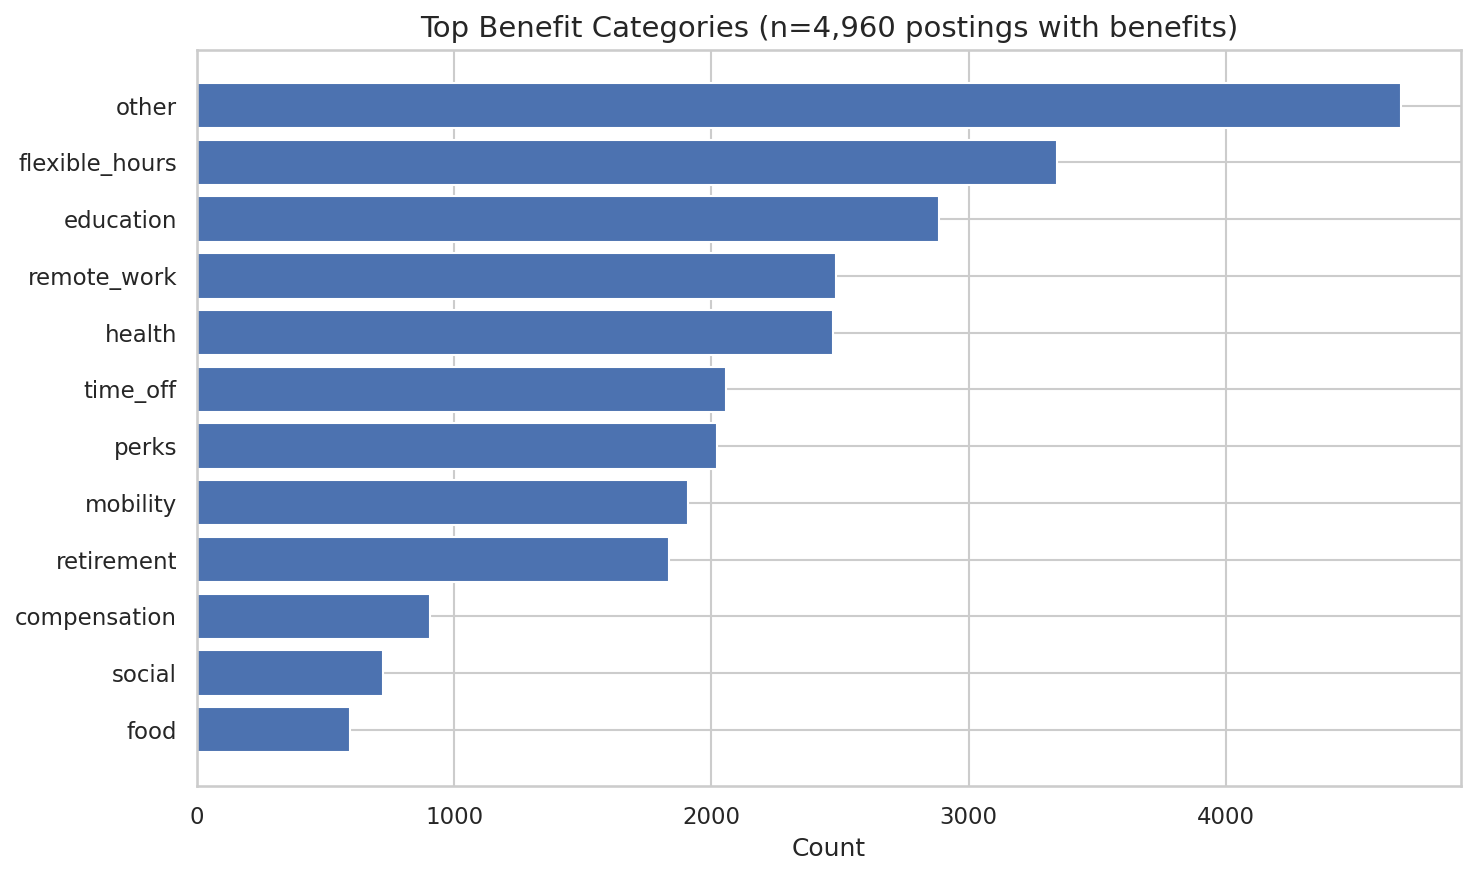

In [4]:
benefit_cats_exploded = explode_json_col(df, "benefit_categories")
n_with_cats = df["benefit_categories"].apply(lambda v: bool(parse_json_list(v))).sum()

horizontal_bar(
    benefit_cats_exploded["benefit_categories"],
    f"Top Benefit Categories (n={n_with_cats:,} postings with benefits)",
    save_as="07_benefits.png",
)

**Takeaway:** Work-life balance perks (flexible hours, home office) and professional development dominate German IT job benefits. Traditional perks like company pension and health programmes also feature prominently, reflecting the German emphasis on long-term employee welfare.

## Benefit Categories × Job Family Heatmap

Postings per family:
  SAP Consultant: n=1,858
  System Administrator: n=1,767
  Software Developer: n=1,606
  Fullstack Developer: n=1,529
  Solution Architect: n=1,140
  Backend Developer: n=795
  Data Engineer: n=776
  Cloud Engineer: n=727


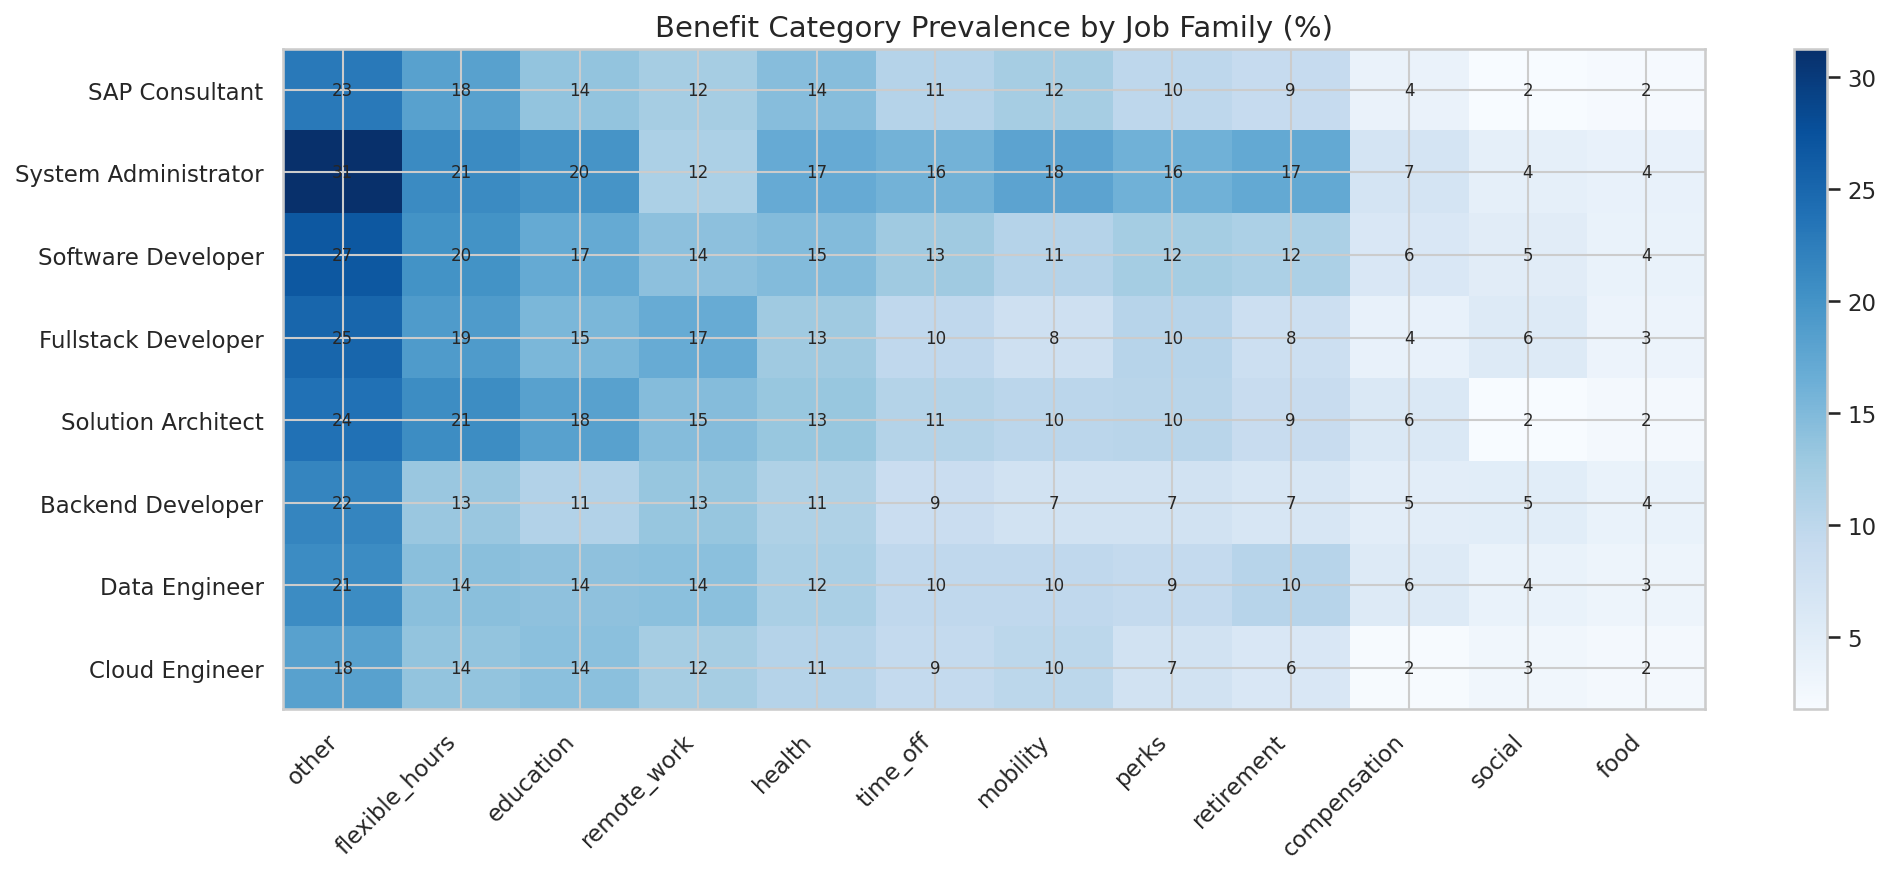

In [5]:
df_fam = exclude_other_family(df)

# Use the compute helper to get benefit prevalence (%) per job family
benefit_fam_pct = benefit_category_by_family(df_fam, top_n_families=8)

# Sort columns by overall prevalence
col_order = benefit_fam_pct.mean().sort_values(ascending=False).index
benefit_fam_pct = benefit_fam_pct[col_order]

# Show family counts for context
fam_counts = df_fam["job_family"].value_counts().head(8)
print("Postings per family:")
for fam in benefit_fam_pct.index:
    print(f"  {fam}: n={fam_counts.get(fam, 0):,}")

heatmap(
    benefit_fam_pct,
    "Benefit Category Prevalence by Job Family (%)",
    figsize=(14, 6),
    save_as="07_benefit_family.png",
)

**Takeaway:** Benefit offerings are broadly similar across IT job families, suggesting that benefits are more company-driven than role-driven. However, some variation exists — for instance, roles with higher seniority expectations may see slightly more emphasis on professional development and flexible working.

## Urlaub (30+ days) Prevalence

Urlaub/vacation mentioned: 1,632 / 18,899 (8.6%)


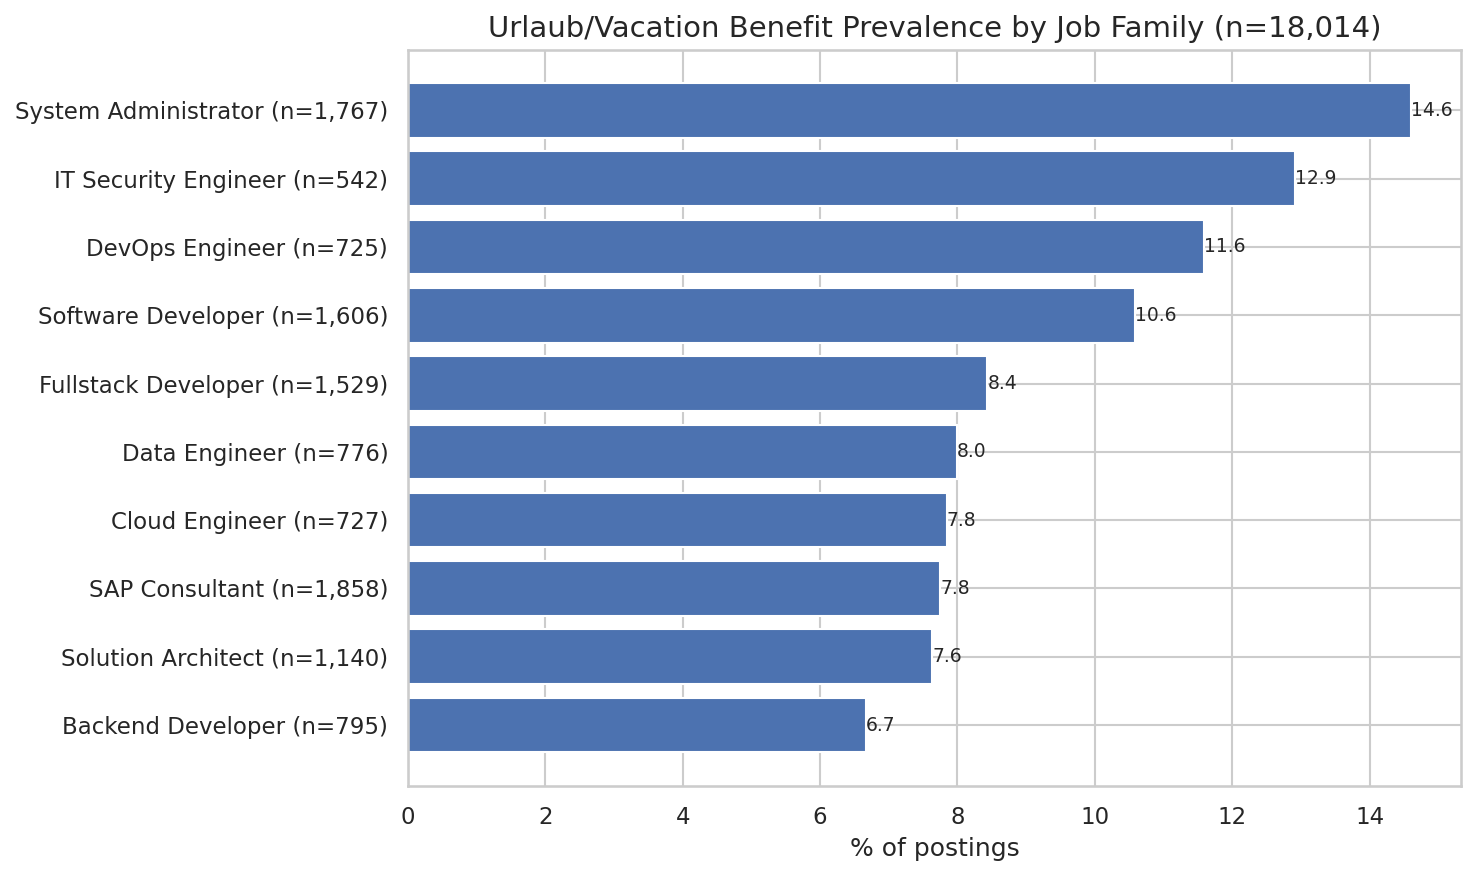

In [6]:
def has_urlaub(benefits_json: object) -> bool:
    """Check if benefits mention Urlaub or vacation."""
    items = parse_json_list(benefits_json)
    return any(
        "urlaub" in b.lower() or "vacation" in b.lower()
        for b in items
    )

df2 = df.copy()
df2["has_urlaub"] = df2["benefits"].apply(has_urlaub)
urlaub_count = df2["has_urlaub"].sum()
total = len(df2)
print(f"Urlaub/vacation mentioned: {urlaub_count:,} / {total:,} ({urlaub_count/total*100:.1f}%)")

# Breakdown by job family
df2_fam = exclude_other_family(df2)
top_families = df2_fam["job_family"].value_counts().head(10).index
family_urlaub = df2_fam[df2_fam["job_family"].isin(top_families)].groupby("job_family")
family_pct = (family_urlaub["has_urlaub"].mean().sort_values() * 100)
family_n = family_urlaub.size()

# Build labels with n= annotation
labels = [f"{fam} (n={family_n[fam]:,})" for fam in family_pct.index]

value_bar(
    labels,
    family_pct.values,
    f"Urlaub/Vacation Benefit Prevalence by Job Family (n={len(df2_fam):,})",
    xlabel="% of postings",
    fmt=".1f",
    save_as="07_urlaub_family.png",
)

**Takeaway:** Explicit mention of generous vacation (Urlaub) varies by role. This likely reflects differences in how companies write postings for different audiences rather than actual differences in vacation entitlement, since German labour law guarantees a baseline of 20 days for all full-time employees.

## Top Companies by Average Benefit Richness

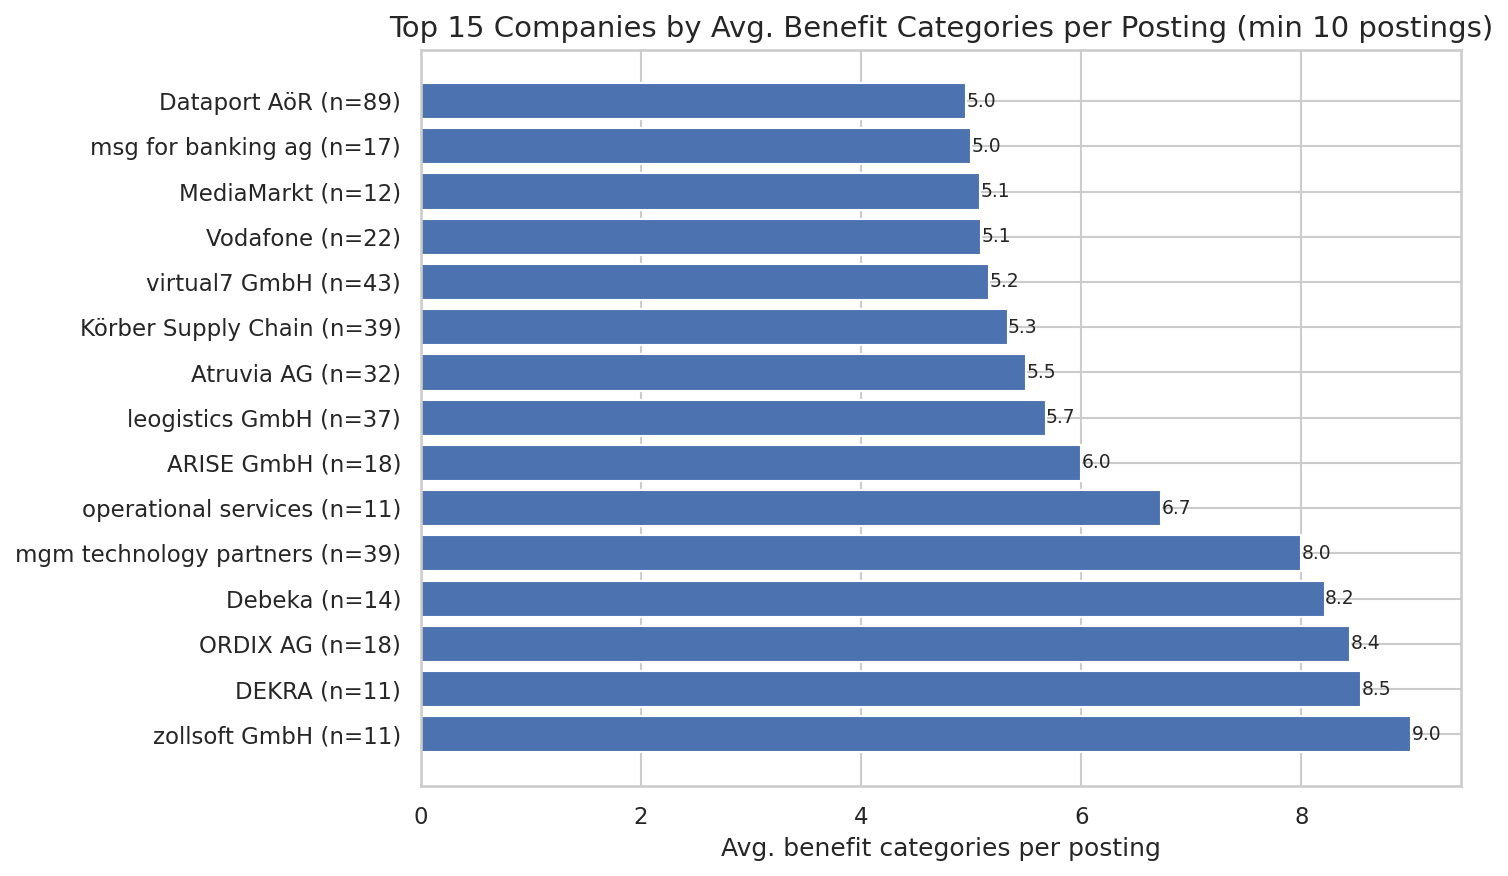

In [7]:
# Normalise: average number of distinct benefit categories per posting
company_df = df[df["company_name"].notna()].copy()
company_df["_n_cats"] = company_df["benefit_categories"].apply(lambda v: len(parse_json_list(v)))

# Only consider companies with enough postings for a meaningful average
company_counts = company_df["company_name"].value_counts()
min_postings = 10
eligible = company_counts[company_counts >= min_postings].index

avg_cats = (
    company_df[company_df["company_name"].isin(eligible)]
    .groupby("company_name")["_n_cats"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

# Build labels with posting count
labels = [f"{c} (n={company_counts[c]:,})" for c in avg_cats.index]

value_bar(
    labels,
    avg_cats.values,
    f"Top 15 Companies by Avg. Benefit Categories per Posting (min {min_postings} postings)",
    xlabel="Avg. benefit categories per posting",
    fmt=".1f",
    save_as="07_company_benefits.png",
)

**Takeaway:** By normalising for posting volume, we see which companies consistently advertise a rich set of benefits rather than simply which companies post the most. Companies that list more benefit categories per posting are likely using benefits as a competitive recruiting tool.